In [7]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy.signal import butter, filtfilt, resample
import pywt


1. Download Dataset

MIT-BIH Arrhythmia Database (https://doi.org/10.13026/C2F305)

In [8]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

2. Visualizing Dataset

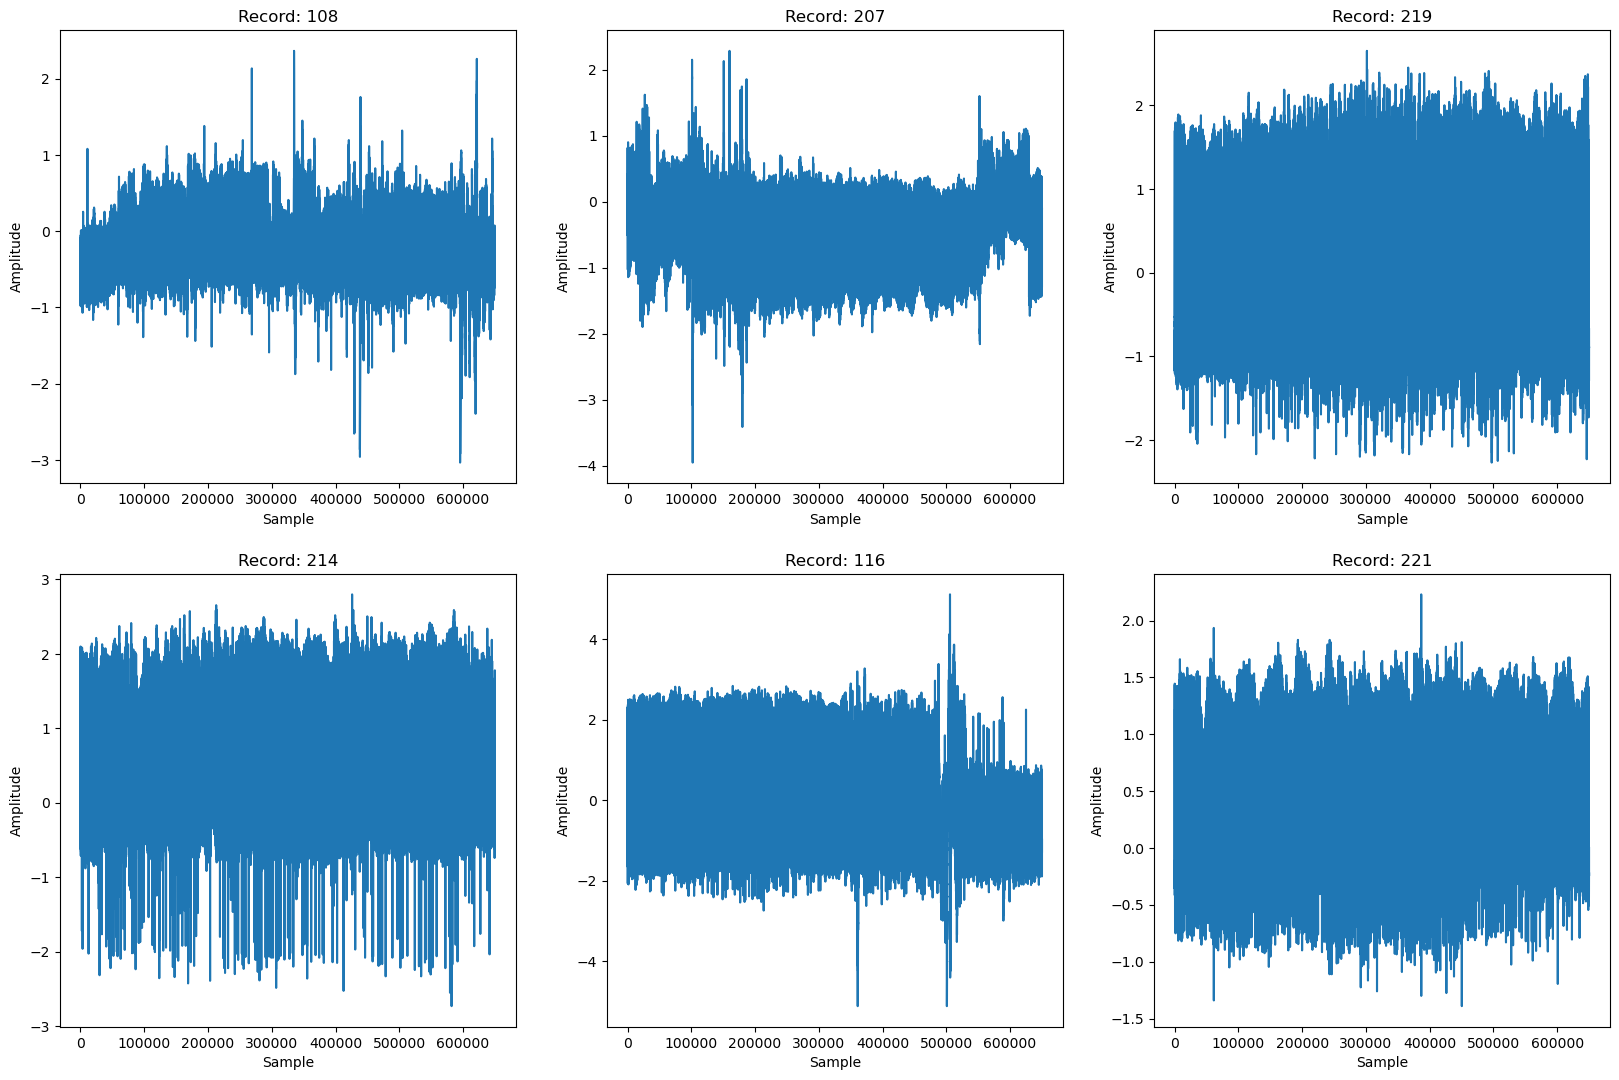

In [9]:
records = [
    f[:-4]
    for f in os.listdir("mitdb")
    if f.endswith(".hea")
]

plt.figure(figsize=(20, 20))

all_classes = os.listdir('mitdb')
random_records = random.sample(records, 6)

for counter, random_record in enumerate(random_records, 1):
    ecg_record = wfdb.rdrecord(f'mitdb/{random_record}')
    plt.subplot(3, 3, counter)
    plt.plot(ecg_record.p_signal[:, 0])
    plt.title(f"Record: {random_record}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")

3. Data Loading

AAMI_MAPPING & CLASS_NAMES: Groups detailed doctor annotations into 5 standard AAMI classes (N, S, V, F, Q) to make labels uniform and ready for model training.

wfdb.rdrecord: Reads the raw continuous ECG signal in physical voltage (mV).

wfdb.rdann: Reads the expert-annotated R-peak timestamps and heartbeat labels.

MLII Detection: Automatically selects the Modified Limb Lead II channel, ensuring consistency across all patient records.

if symbol in AAMI_MAPPING: Keeps only valid heartbeats and removes non-beat markers (such as noise artifacts or rhythm changes).

In [10]:
AAMI_MAPPING = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    'V': 2, 'E': 2,
    'F': 3,
    '/': 4, 'f': 4, 'Q': 4
}
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
def load_mitdb_record(record_name, data_dir='mitdb'):
    record_path = os.path.join(data_dir, str(record_name))
    
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, 'atr')
    
    fs = record.fs
    lead_idx = record.sig_name.index('MLII') if 'MLII' in record.sig_name else 0
    signal = record.p_signal[:, lead_idx]
    
    r_peaks = []
    labels = []
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol in AAMI_MAPPING:
            r_peaks.append(sample)
            labels.append(AAMI_MAPPING[symbol])
            
    return signal, np.array(r_peaks, dtype=int), np.array(labels, dtype=int), fs

4. Filtering

filter_butterworth (Scenario 2):

- Uses a bandpass filter between 0.5 Hz and 45 Hz.
- Eliminates baseline drift (breathing movements below 0.5 Hz) and electrical powerline noise (above 45 Hz).
- Uses filtfilt (forward-backward filtering) to prevent phase distortion, ensuring the R-peak position does not shift.

filter_dwt_sym10 (Scenario 3):

- Breaks down the signal into 8 frequency levels using the Symlet-10 (sym10) wavelet, whose mathematical shape closely matches the ECG QRS complex.
- coeffs[0] = 0: Removes the lowest frequency component (baseline wander).
- coeffs[1] & coeffs[2] = 0: Removes high-frequency noise and powerline interference.
- Reconstructs a clean ECG signal while preserving the sharp peaks of heartbeats.

In [11]:
def filter_butterworth(signal, fs=360, lowcut=0.5, highcut=45.0, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='bandpass')
    return filtfilt(b, a, signal)

def filter_dwt_sym10(signal, wavelet='sym10', level=8):
    coeffs = pywt.wavedec(signal, wavelet=wavelet, level=level)
    coeffs[0] = np.zeros_like(coeffs[0])
    coeffs[1] = np.zeros_like(coeffs[1])
    coeffs[2] = np.zeros_like(coeffs[2])
    return pywt.waverec(coeffs, wavelet=wavelet)[:len(signal)]

5. Normalization 

normalize_minmax (Scenario 4):

- Scales all voltage values strictly into the bounded range of [−1,1].
- Prevents large amplitude spikes from dominating gradient updates during neural network backpropagation.

normalize_zscore (Scenario 5):

- Transforms the signal distribution to have a mean of μ=0 and standard deviation of σ=1.
- Centers the baseline at zero and standardizes variability across different patients and electrode placements.

eps=1e-8:

- A tiny constant (epsilon) added to the denominator to prevent a ZeroDivisionError if the signal happens to be completely flat.

In [12]:
def normalize_minmax(signal, feature_range=(-1, 1), eps=1e-8):
    min_val = np.min(signal)
    max_val = np.max(signal)
    a, b = feature_range
    normalized = (signal - min_val) / (max_val - min_val + eps)
    return a + normalized * (b - a)

def normalize_zscore(signal, eps=1e-8):
    mean = np.mean(signal)
    std = np.std(signal)
    return (signal - mean) / (std + eps)

6. Resample

resample_record (Used in Scenarios 6 & 7):

- Downsampling: Reduces sampling rate from the original 360 Hz down to 100 Hz or 50 Hz using scipy.signal.resample.

- Time Scaling: Recalculates the exact position of each R-peak by multiplying with target_fs / original_fs, keeping the annotations - perfectly aligned with the newly scaled signal.

extract_beats (Heartbeat Segmentation):

- Beat Windowing: Cuts each continuous signal into individual heartbeats centered around the detected R-peaks.
- Window Proportions:
    - 0.3 seconds before R-peak: Captures atrial depolarization (P-wave and PR segment).
    - 0.5 seconds after R-peak: Captures ventricular repolarization (ST segment and T-wave).
- Boundary Guard: Safely skips beats that are too close to the beginning or end of the recording to prevent out-of-bounds indexing.
- Output Shape: Produces a 2D array (num_beats, window_length) ready to be reshaped into (num_beats, window_length, 1) for 1D CNN-LSTM input.

In [14]:
def resample_record(signal, r_peaks, original_fs=360, target_fs=100):
    if target_fs == original_fs:
        return signal, r_peaks, original_fs
        
    num_samples = int(len(signal) * (target_fs / original_fs))
    resampled_signal = resample(signal, num_samples)
    
    scale_factor = target_fs / original_fs
    resampled_r_peaks = np.round(r_peaks * scale_factor).astype(int)
    
    return resampled_signal, resampled_r_peaks, target_fs
def extract_beats(signal, r_peaks, labels, fs, before_sec=0.3, after_sec=0.5):
    half_before = int(before_sec * fs)
    half_after = int(after_sec * fs)
    total_len = half_before + half_after
    
    beats = []
    valid_labels = []
    
    for r_peak, label in zip(r_peaks, labels):
        start = r_peak - half_before
        end = r_peak + half_after
        
        if start >= 0 and end <= len(signal):
            segment = signal[start:end]
            if len(segment) == total_len:
                beats.append(segment)
                valid_labels.append(label)
                
    return np.array(beats, dtype=np.float32), np.array(valid_labels, dtype=int)